In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("Project_recordings_data.pkl", "rb") as f:
    data = pickle.load(f)

# Introduction

You will have to preprocess and analyse electrophysiological data from intracranial recordings perfomed in a single cat primary visual cortex (V1). The cat in this task was sedated and passively looking at a screnn on which some oriented bars where showed. In total 18 orientations were presented from 0 degree (flat bar) to 170 degree. Each orientation was presented 20 times. A bit of preprocessing was already done, a total of 30 neurons were found in the recordings. 

In the data file loaded above you may find the recordings in dictionnary. Keys are the orientations from '0' to '170', plus 'time' corresponding to the recordings time points. 

![Screenshot 2026-05-13 alle 15.18.15.png](<attachment:Screenshot 2026-05-13 alle 15.18.15.png>)
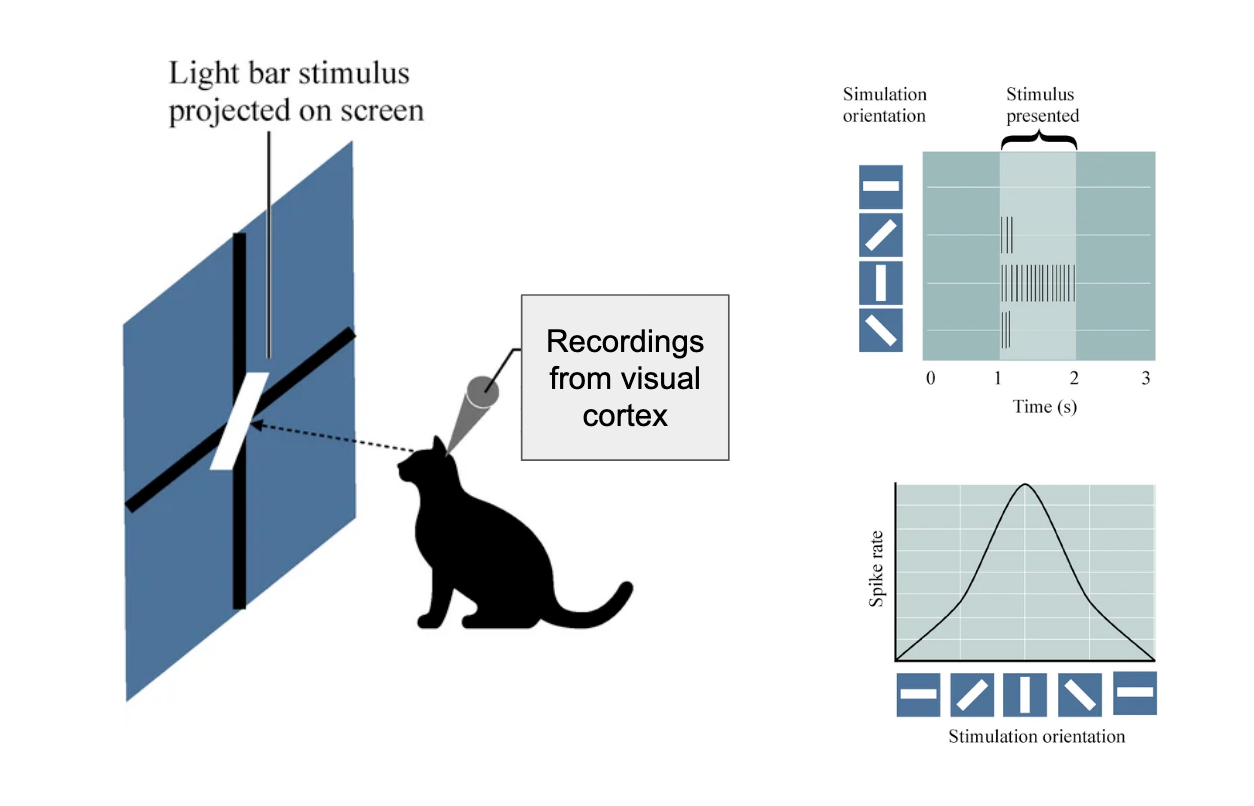

In [2]:
# Printing the keys
print(data.keys())

time = data.pop("time")

dict_keys(['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100', '110', '120', '130', '140', '150', '160', '170', 'time'])


In [3]:
print(type(data["0"]))

<class 'dict'>


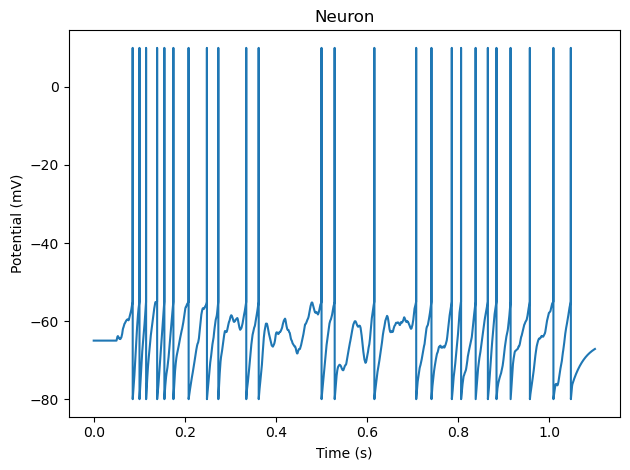

In [5]:
fig, ax = plt.subplots(1,1)

ax.plot(time, data["0"]["neuron1"][0])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Potential (mV)")
ax.set_title("Neuron")
plt.tight_layout()

In [6]:
# sc.signal.find_peaks(sim, height=0)[0].shape[0]

In [24]:
nbr_simulated_neurons = 30
nbr_repetion = 20
# Processing
firing_rates = []
for i in range(nbr_simulated_neurons):
    fr = []
    for key in data.keys():
        fr.append(np.sum(np.asarray(data[f"{key}"][f"neuron{1+i}"])>0, axis=1))
    firing_rates.append(fr)


print(np.shape(firing_rates))
Orientations = np.arange(0, 180, 10)

(30, 18, 20)


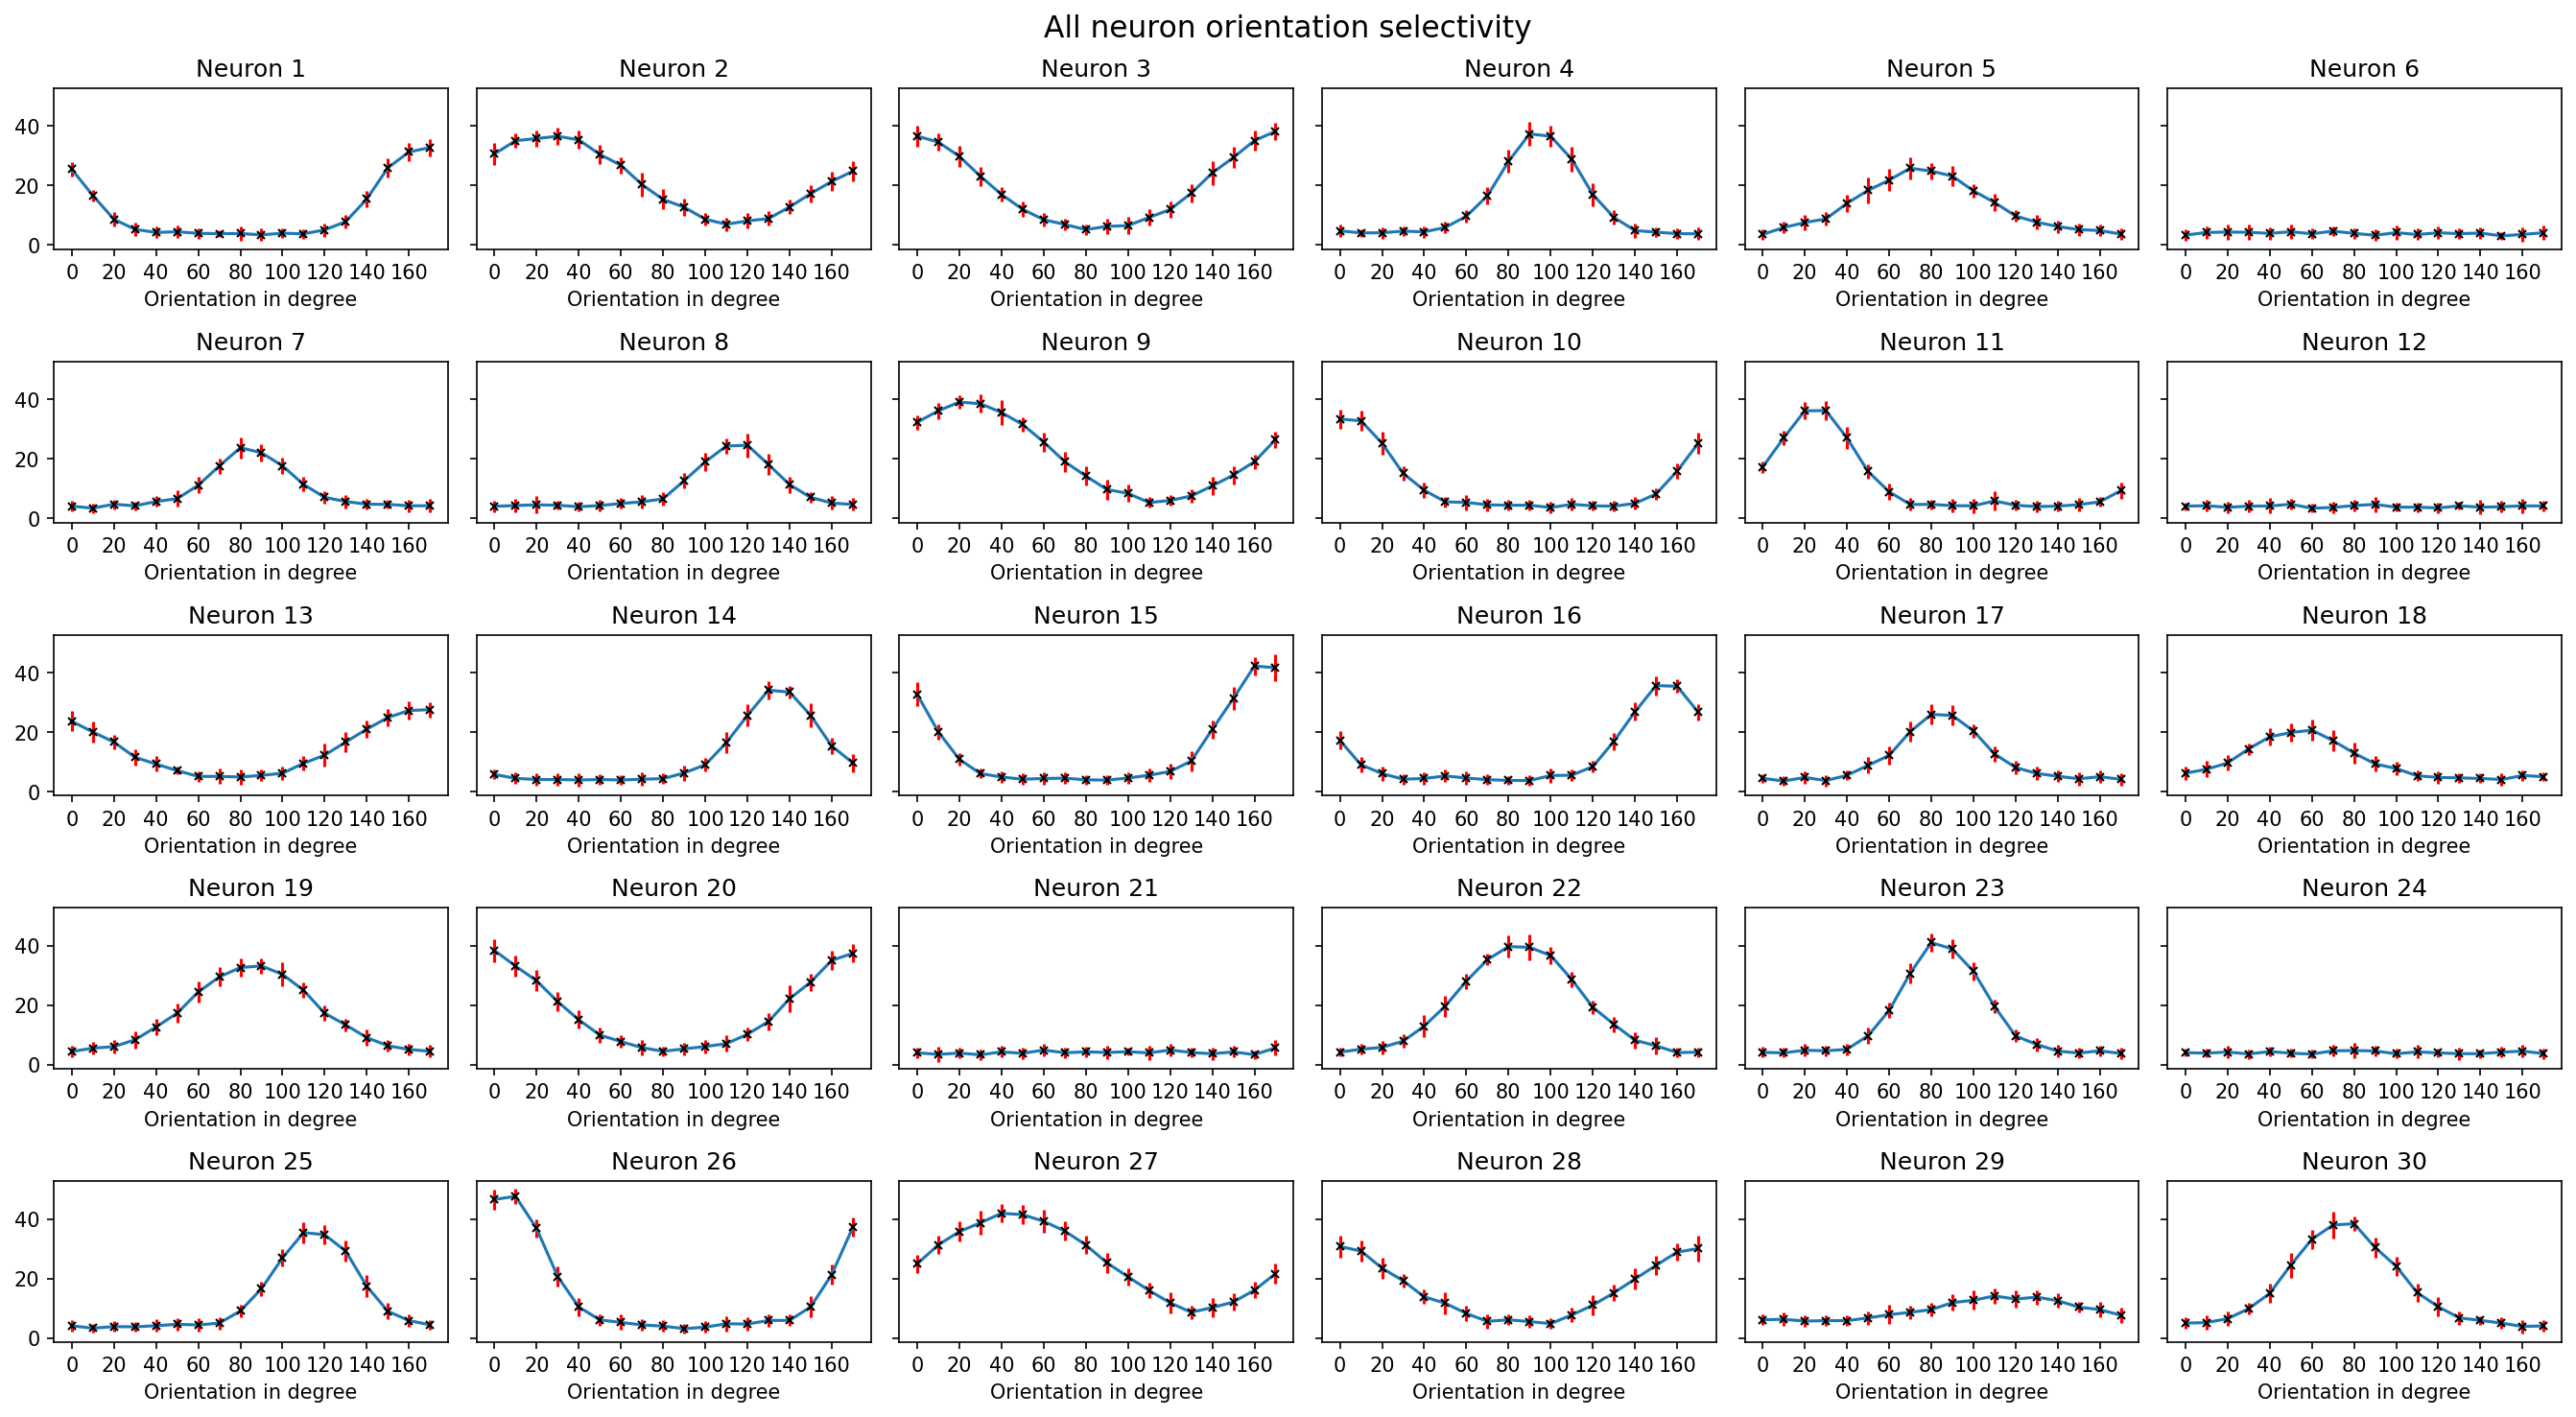

In [25]:
fig, axes = plt.subplots(5,6, figsize=(18, 10), dpi=150, sharey=True)
ax = axes.flatten()

for i in range(nbr_simulated_neurons):
    ax[i].errorbar(Orientations, np.mean(firing_rates[i], axis=1), np.std(firing_rates[i], axis=1), linestyle='-', marker='x', markersize=4, ecolor="red", markeredgecolor="k")
    ax[i].set_xticks(Orientations[::2])
    ax[i].set_xticklabels(Orientations[::2])
    ax[i].set_xlabel("Orientation in degree")
    ax[i].set_title(f"Neuron {i+1}")
fig.suptitle("All neuron orientation selectivity", fontsize=15)
plt.tight_layout()


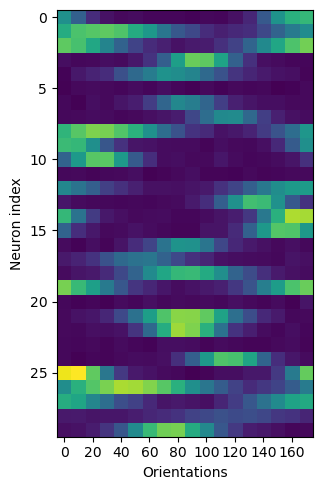

In [43]:
fig, ax = plt.subplots(1,1, figsize=(12, 5))
ax.imshow(np.mean(firing_rates, axis=2))
ax.set_xticks(np.arange(0,18, 2))
ax.set_xticklabels(Orientations[::2])
ax.set_ylabel("Neuron index")
ax.set_xlabel("Orientations")
plt.tight_layout()

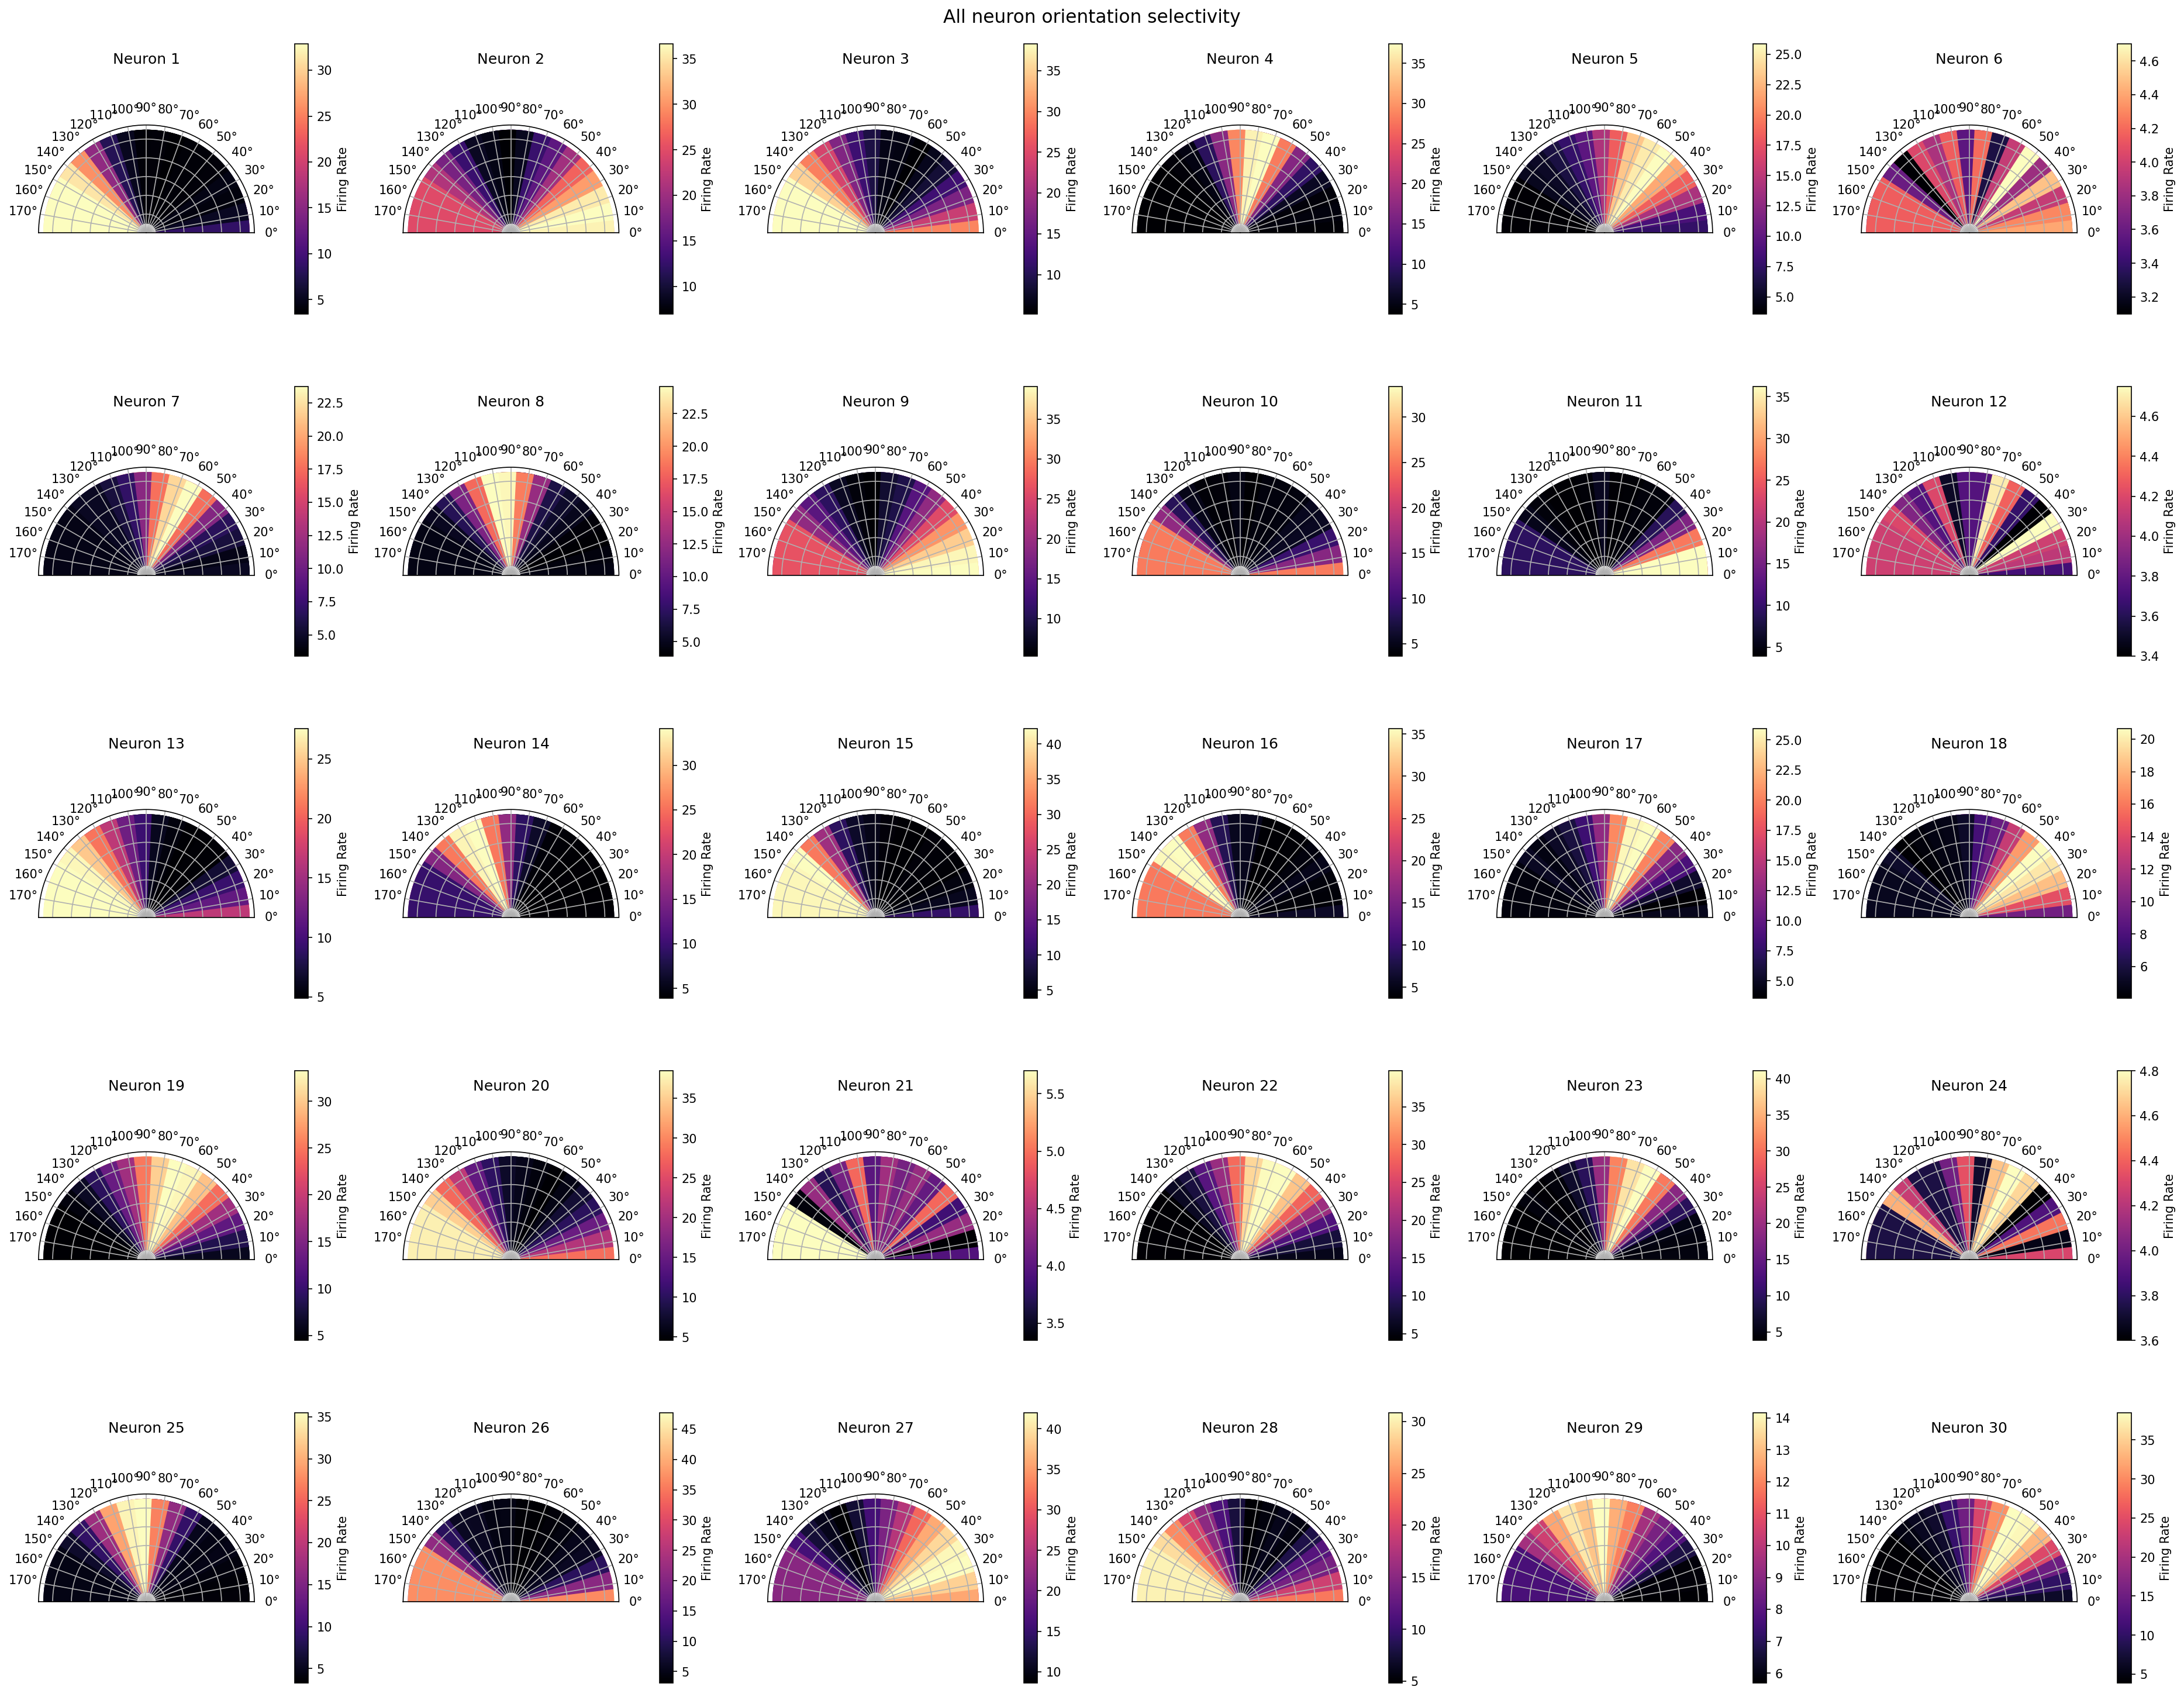

In [27]:
import matplotlib

fig, axes = plt.subplots(5,6, figsize=(25, 20), dpi=150, subplot_kw={'projection': 'polar'})
ax = axes.flatten()

for i in range(nbr_simulated_neurons):
    theta = np.deg2rad(Orientations)
    rates = np.mean(firing_rates[i], axis=1)
    norm = plt.Normalize(rates.min(), rates.max())
    colors = matplotlib.cm.magma(norm(rates))
    
    bars = ax[i].bar(x=theta, height=1,bottom=0.1,color=colors, edgecolor=None,linewidth=0)
    ax[i].set_title(f"Neuron {i+1}")
    ax[i].set_theta_zero_location('N')
    ax[i].set_yticklabels([])
    ax[i].set_xticks(np.deg2rad(Orientations))
    ax[i].set_thetamin(Orientations[0])
    ax[i].set_thetamax(180)
    ax[i].set_theta_direction(1) 
    ax[i].set_theta_offset(0)
    sm = matplotlib.cm.ScalarMappable(cmap='magma', norm=norm)
    plt.colorbar(sm, ax=ax[i], label='Firing Rate', pad=0.15, fraction=0.05)
fig.suptitle("All neuron orientation selectivity", fontsize=15)
plt.tight_layout()